# Evaluating and Tuning Your Models

##  Learning Outcomes

After this video, you'll be able to:

<ul>
    <li>Implement key evaluation metrics</li>
    <li>Visualize model performance</li>
    <li>Tune hyperparameters efficiently</li>
    <li>Work within AWS resource constraints</li>
</ul>

## Setup and Data Preparation

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             roc_curve, auc, f1_score)
import matplotlib.pyplot as plt
import time

In [2]:
df = pd.read_csv('insightlysoft_dataset.csv')
X = df.drop(['churned', 'account_id'], axis=1).select_dtypes(include=[np.number])
y = df['churned']

## Model Evaluation Implementation

In [3]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [4]:
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [5]:
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]

## Visualization of Metrics

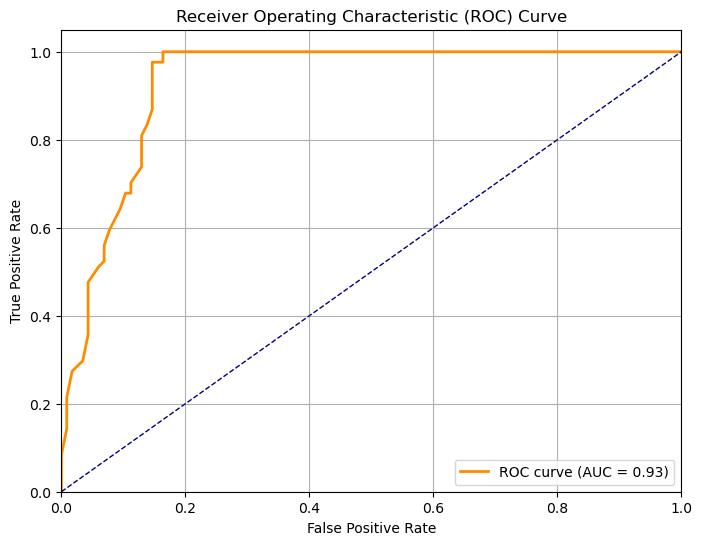

In [6]:
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2,
         label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=1, linestyle='--')  # Diagonal line
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

## Hyperparameter Tuning

In [7]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    'n_estimators': [50, 100, 150],
    'max_depth': [3, 5, 7],
    'min_samples_split': [2, 5, 10]
}


In [8]:
random_search = RandomizedSearchCV(
    RandomForestClassifier(random_state=42),
    param_distributions=param_dist,
    n_iter=10,  # Limited iterations for free tier
    cv=3,       # Smaller CV for efficiency
    n_jobs=-1   # Use all available cores
)

random_search.fit(X_train, y_train)

RandomizedSearchCV(cv=3, estimator=RandomForestClassifier(random_state=42),
                   n_jobs=-1,
                   param_distributions={'max_depth': [3, 5, 7],
                                        'min_samples_split': [2, 5, 10],
                                        'n_estimators': [50, 100, 150]})

## Comparing Results

In [9]:
def print_metrics(y_true, y_pred, model_name):
    metrics = {
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred),
        'Recall': recall_score(y_true, y_pred),
        'F1': f1_score(y_true, y_pred)
    }
    
    print(f"\n{model_name} Performance Metrics:")
    for metric, value in metrics.items():
        print(f"{metric}: {value:.3f}")
        
    return metrics

# Compare baseline and tuned models
baseline_metrics = print_metrics(y_test, y_pred, "Baseline Model")
tuned_metrics = print_metrics(
    y_test, 
    random_search.predict(X_test), 
    "Tuned Model"
)



Baseline Model Performance Metrics:
Accuracy: 0.905
Precision: 0.828
Recall: 0.976
F1: 0.896

Tuned Model Performance Metrics:
Accuracy: 0.900
Precision: 0.814
Recall: 0.988
F1: 0.892


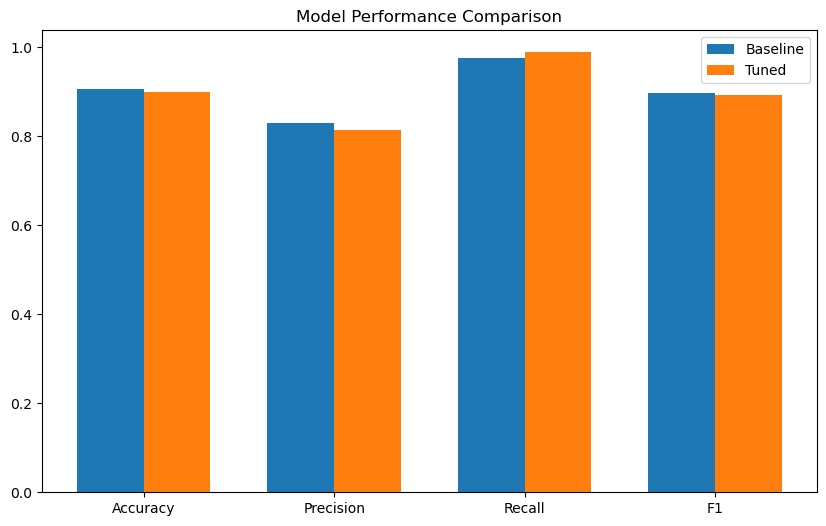

In [10]:
plt.figure(figsize=(10, 6))
x = np.arange(len(baseline_metrics))
width = 0.35

plt.bar(x - width/2, baseline_metrics.values(), width, label='Baseline')
plt.bar(x + width/2, tuned_metrics.values(), width, label='Tuned')
plt.xticks(x, baseline_metrics.keys())
plt.title('Model Performance Comparison')
plt.legend()
plt.show()


## Pratical Implementation Considerations

In [11]:
import joblib
import os

def check_resource_usage(model, X, filename='temp_model.pkl'):
    # Model size
    joblib.dump(model, filename)
    model_size = os.path.getsize(filename) / 1024**2
    os.remove(filename)
    print(f"Model size: {model_size:.2f} MB")

    # Prediction time
    start_time = time.time()
    model.predict(X[:1000])
    pred_time = time.time() - start_time
    print(f"Prediction time (1000 samples): {pred_time:.3f} seconds")

check_resource_usage(random_search.best_estimator_, X_test)

Model size: 0.12 MB
Prediction time (1000 samples): 0.006 seconds


## Recap


In this video, we covered:

- Implementing key evaluation metrics 

- Creating informative visualizations 

- Performing efficient hyperparameter tuning 

- Working within free tier constraints
